In [1]:
from kan import *
import torch
torch.cuda.empty_cache()
import os

In [2]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu" )
print(device)

cuda:3


In [3]:
tju_dataset = torch.load('../Data/TJU_Data_Var2_batch_2.pt')

/tmp/ipykernel_1877528/1821787339.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tju_dataset = torch.load('../Data/TJU_Data_Var2_batch_2.pt')


In [4]:
train_loader = tju_dataset['train_loader']
valid_loader = tju_dataset['valid_loader']
test_loader = tju_dataset['test_loader']

In [5]:
import argparse
def get_args():
    parser = argparse.ArgumentParser('Hyper Parameters for TJU dataset')
    parser.add_argument('--model_name',type=str,default='PIKAN')
    parser.add_argument('--data', type=str, default='TJU', help='XJTU, HUST, MIT, TJU')
    parser.add_argument('--batch_size', type=int, default=512, help='batch size')
    parser.add_argument('--normalization_method', type=str, default='min-max', help='min-max,z-score')

    parser.add_argument('--epochs', type=int, default=200, help='epoch')
    parser.add_argument('--early_stop', type=int, default=20, help='early stop')
    parser.add_argument('--warmup_epochs', type=int, default=30, help='warmup epoch')
    parser.add_argument('--warmup_lr', type=float, default=0.002, help='warmup lr')
    parser.add_argument('--lr', type=float, default=0.01, help='base lr')
    parser.add_argument('--final_lr', type=float, default=0.0002, help='final lr')
    parser.add_argument('--lr_F', type=float, default=0.001, help='lr of F')

    parser.add_argument('--alpha', type=float, default=1, help='loss = l_data + alpha * l_PDE + beta * l_physics')
    parser.add_argument('--beta', type=float, default=0.001, help='loss = l_data + alpha * l_PDE + beta * l_physics')

    parser.add_argument('--ckpt_path', type=str, default='../Notebooks/ckpt_path/pikan_tju_var2/')
    parser.add_argument('--log_dir', type=str, default='logging.txt', help='log dir, if None, do not save')
    parser.add_argument('--save_folder', type=str, default='../Notebooks/results_of_pikan/TJU results/pikan_fit_1', help='save folder')
    parser.add_argument('--image_folder', type=str, default='../Images/pikan_tju_var2/video_img_fit_1', help='save folder')
    parser.add_argument('--save_fig', type=bool, default=True, help='whether to save video image')
    parser.add_argument('--f_in_vars', type=list, default=[r'$x$', r'$t$'], help='the input variables of solution_u')
    parser.add_argument('--f_out_vars', type=list, default=[r'$u$'], help='the output variable of solution_u')
    parser.add_argument('--g_in_vars', type=list, default=[r'$x$', r'$t$',r'$u$', r'$u_x$'], help='the input variables of dynamical_F')
    parser.add_argument('--g_out_vars', type=list, default=[r'$u_t$'], help='the output variable of dynamical_F')
    parser.add_argument('--mark', type=str, default='0.0', help='the version of pikan')
    
    args = parser.parse_args([])    # 传入空列表，避免解析 Jupyter 注入的参数
    return args
args = get_args()

In [6]:
import logging
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error
def set_seed(seed):
    if seed is None:
        seed = np.random.randint(1e6)
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) # 为了禁止hash随机化，使得实验可复现。
    torch.manual_seed(seed) # 为CPU设置随机种子
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed) # 为当前GPU设置随机种子
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU，为所有GPU设置随机种子
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

def get_logger(log_name='log.txt'):
    logger = logging.getLogger('mylogger')
    logger.setLevel(level=logging.DEBUG)
    formatter = logging.Formatter('%(asctime)s - function:%(funcName)s - %(levelname)s - %(message)s',datefmt='%Y-%m-%d %H:%M')

    # console = logging.StreamHandler()
    # console.setLevel(logging.INFO)
    # console.setFormatter(formatter)
    # logger.addHandler(console)

    if log_name is not None:
        handler = logging.FileHandler(log_name)
        handler.setLevel(logging.DEBUG)
        handler.setFormatter(formatter)
        logger.addHandler(handler)

    return logger

class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def eval_metrix(true_label,pred_label):
    MAE = mean_absolute_error(true_label,pred_label)
    MAPE = mean_absolute_percentage_error(true_label,pred_label)
    MSE = mean_squared_error(true_label,pred_label)
    RMSE = np.sqrt(mean_squared_error(true_label,pred_label))

    return [MAE,MAPE,MSE,RMSE]

In [7]:
from torch.autograd import grad
class LR_Scheduler(object): # 用于调整优化器的学习率
    def __init__(self, optimizer, warmup_epochs, warmup_lr, num_epochs, base_lr, final_lr, iter_per_epoch=1,
                 constant_predictor_lr=False):  # 优化器、预热期的轮数、预热期的学习率、总轮数、基础学习率、最终学习率
        self.base_lr = base_lr
        self.constant_predictor_lr = constant_predictor_lr
        warmup_iter = iter_per_epoch * warmup_epochs
        warmup_lr_schedule = np.linspace(warmup_lr, base_lr, warmup_iter)   # 预热期的学习率序列，线性热身，从warmup_lr线性增加到base_lr
        decay_iter = iter_per_epoch * (num_epochs - warmup_epochs)
        cosine_lr_schedule = final_lr + 0.5 * (base_lr - final_lr) * (
                    1 + np.cos(np.pi * np.arange(decay_iter) / decay_iter)) # 衰减期的余弦学习率序列，余弦退火，从base_lr逐渐下降到final_lr，并且下降的过程是按照余弦函数的形状进行的

        self.lr_schedule = np.concatenate((warmup_lr_schedule, cosine_lr_schedule)) # 完整的学习率序列
        self.optimizer = optimizer
        self.iter = 0
        self.current_lr = 0

    def step(self): # 在每次调用时，根据当前迭代次数为优化器的参数组设置学习率
        for param_group in self.optimizer.param_groups:

            if self.constant_predictor_lr and param_group['name'] == 'predictor':   # 特殊情况，学习率保持不变
                param_group['lr'] = self.base_lr
            else:
                lr = param_group['lr'] = self.lr_schedule[self.iter]    # 学习率调整策略

        self.iter += 1
        self.current_lr = lr
        return lr

    def get_lr(self):
        return self.current_lr
    
class PIKAN(nn.Module):
    def __init__(self,args):
        super(PIKAN, self).__init__()
        self.args = args
        if args.save_folder is not None and not os.path.exists(args.save_folder):   # 保存传入的参数
            os.makedirs(args.save_folder)
        if args.image_folder is not None and not os.path.exists(args.image_folder):   # 保存传入的参数
            os.makedirs(args.image_folder)
            os.makedirs(args.image_folder+'/solution_u')
            os.makedirs(args.image_folder+'/dynamical_F')
        log_dir = args.log_dir if args.save_folder is None else os.path.join(args.save_folder, args.log_dir)    # 根据参数创建日志目录
        self.logger = get_logger(log_dir)   # 初始化日志记录器
        self._save_args()
        
        if args.mark == '0.0':
            self.solution_u = KAN(width=[2,4,1], grid=3, k=3, seed=25, ckpt_path=args.ckpt_path + 'solution_u/',device=device)   # 求解偏微分方程解的网络
            self.dynamical_F = KAN(width=[4,2,1], grid=3, k=3, seed=25, ckpt_path=args.ckpt_path + 'dynamical_F/',device=device) # 用于计算动态方程的网络
        else:
            self.solution_u = KAN.loadckpt(args.ckpt_path + 'solution_u/'+args.mark)   # 求解偏微分方程解的网络
            self.dynamical_F = KAN.loadckpt(args.ckpt_path + 'dynamical_F/'+args.mark) # 用于计算动态方程的网络

        self.optimizer1 = torch.optim.Adam(self.solution_u.parameters(), lr=args.warmup_lr)
        self.optimizer2 = torch.optim.Adam(self.dynamical_F.parameters(), lr=args.lr_F)

        self.scheduler = LR_Scheduler(optimizer=self.optimizer1,
                                      warmup_epochs=args.warmup_epochs,
                                      warmup_lr=args.warmup_lr,
                                      num_epochs=args.epochs,
                                      base_lr=args.lr,
                                      final_lr=args.final_lr)

        self.loss_func = nn.MSELoss()
        self.relu = nn.ReLU()

        # 模型的最好参数(the best model)
        self.best_model = None

        # loss = loss1 + alpha*loss2 + beta*loss3
        self.alpha = self.args.alpha
        self.beta = self.args.beta

    def _save_args(self):
        if self.args.log_dir is not None:
            # 中文： 把parser中的参数保存在self.logger中
            # English: save the parameters in parser to self.logger
            self.logger.info("Args:")
            for k, v in self.args.__dict__.items():
                self.logger.critical(f"\t{k}:{v}")

    def clear_logger(self):
        self.logger.removeHandler(self.logger.handlers[0])
        self.logger.handlers.clear()

    def predict(self,xt):
        return self.solution_u(xt)

    def Test(self,testloader):  # 在测试数据集上进行测试，返回真实标签和预测标签
        self.eval()
        true_label = []
        pred_label = []
        with torch.no_grad():
            for iter,(x1,_,y1,_) in enumerate(testloader):
                x1 = x1.to(device)
                u1 = self.predict(x1)
                true_label.append(y1.cpu().detach().numpy())
                pred_label.append(u1.cpu().detach().numpy())
        pred_label = np.concatenate(pred_label,axis=0)
        true_label = np.concatenate(true_label,axis=0)

        return true_label,pred_label

    def Valid(self,validloader):    # 在验证数据集上进行验证，返回均方误差
        self.eval()
        true_label = []
        pred_label = []
        with torch.no_grad():
            for iter,(x1,_,y1,_) in enumerate(validloader):
                x1 = x1.to(device)
                u1 = self.predict(x1)
                true_label.append(y1.cpu().detach().numpy())
                pred_label.append(u1.cpu().detach().numpy())
        pred_label = np.concatenate(pred_label,axis=0)
        true_label = np.concatenate(true_label,axis=0)
        mse = self.loss_func(torch.tensor(pred_label),torch.tensor(true_label))
        return mse.item()

    def forward(self,xt):   # 执行前向传播，计算偏微分方程的解和动态方程的值
        xt.requires_grad = True
        x = xt[:,0:-1]
        t = xt[:,-1:]

        u = self.solution_u(torch.cat((x,t),dim=1))

        u_t = grad(u.sum(),t,   # grad函数要求对一个标量求导
                   create_graph=True,   # 在计算梯度的过程中创建计算图
                   only_inputs=True,    # 只计算关于输入变量（这里就是t或x）的梯度，忽略其他中间变量的梯度计算
                   allow_unused=True)[0]    #  允许输入变量在求导表达式中未被使用的情况（比如某些边界条件下部分变量的导数可能不存在等情况），避免出现报错。
                                            # 最终从grad函数返回的结果中取第一个元素（因为返回的是一个包含梯度的元组，这里只取我们需要的偏导数张量），分别得到关于时间的偏导数u_t和关于空间的偏导数u_x。
        u_x = grad(u.sum(),x,
                   create_graph=True,
                   only_inputs=True,
                   allow_unused=True)[0]

        F = self.dynamical_F(torch.cat([xt,u,u_x],dim=1))

        f = u_t - F
        return u,f

    def train_one_epoch(self,epoch,dataloader):
        self.train()
        loss1_meter = AverageMeter()    # 记录损失的总和以及计算的次数，方便后续求平均损失
        loss2_meter = AverageMeter()
        loss3_meter = AverageMeter()
        for iter,(x1,x2,y1,y2) in enumerate(dataloader):
            x1,x2,y1,y2 = x1.to(device),x2.to(device),y1.to(device),y2.to(device)
            u1,f1 = self.forward(x1)
            u2,f2 = self.forward(x2)

            # data loss
            loss1 = 0.5*self.loss_func(u1,y1) + 0.5*self.loss_func(u2,y2)

            # PDE loss
            f_target = torch.zeros_like(f1)
            loss2 = 0.5*self.loss_func(f1,f_target) + 0.5*self.loss_func(f2,f_target)

            # physics loss  u2-u1<0, considering capacity regeneration
            loss3 = self.relu(torch.mul(u2-u1,y1-y2)).sum() # 确保真实值和预测值的单调性是一致的

            # total loss
            loss = loss1 + self.alpha*loss2 + self.beta*loss3

            self.optimizer1.zero_grad()
            self.optimizer2.zero_grad()
            loss.backward()
            self.optimizer1.step()
            self.optimizer2.step()

            loss1_meter.update(loss1.item())
            loss2_meter.update(loss2.item())
            loss3_meter.update(loss3.item())

            if (iter+1) % 50 == 0:
                info = "[epoch:{} iter:{}] data loss:{:.6f}, PDE loss:{:.6f}, physics loss:{:.6f}".format(epoch,iter+1,loss1,loss2,loss3)
                self.logger.info(info)
        return loss1_meter.avg,loss2_meter.avg,loss3_meter.avg

    def Train(self,trainloader,validloader=None,testloader=None):
        min_valid_mse = 10
        valid_mse = 10
        early_stop = 0
        best_fit_first = True
        for e in range(1,self.args.epochs+1):
            early_stop += 1
            loss1,loss2,loss3 = self.train_one_epoch(e,trainloader)
            current_lr = self.scheduler.step()
            info = '[Train] epoch:{}, lr:{:.6f}, ' \
                   'total loss:{:.6f}'.format(e,current_lr,loss1+self.alpha*loss2+self.beta*loss3)
            self.logger.info(info)
            if e % 1 == 0 and validloader is not None:
                valid_mse = self.Valid(validloader)
                info = '[Valid] epoch:{}, MSE: {}'.format(e,valid_mse)
                self.logger.info(info)
            if valid_mse < min_valid_mse and testloader is not None:
                min_valid_mse = valid_mse
                true_label,pred_label = self.Test(testloader)
                [MAE, MAPE, MSE, RMSE] = eval_metrix(pred_label, true_label)
                info = '[Test] MSE: {:.8f}, MAE: {:.6f}, MAPE: {:.6f}, RMSE: {:.6f}'.format(MSE, MAE, MAPE, RMSE)
                self.logger.info(info)
                early_stop = 0

                ############################### save ############################################
                self.best_model = {'solution_u':self.solution_u.state_dict(),
                                   'dynamical_F':self.dynamical_F.state_dict()}
                if best_fit_first:
                    self.solution_u.log_history('best_fit')
                    self.dynamical_F.log_history('best_fit')
                    round = self.solution_u.round
                    state_id = self.solution_u.state_id
                    best_fit_first = False
                else:
                    self.solution_u.saveckpt(args.ckpt_path + 'solution_u/'+str(round)+'.'+str(state_id))
                    self.dynamical_F.saveckpt(args.ckpt_path + 'dynamical_F/'+str(round)+'.'+str(state_id))
                if self.args.save_folder is not None:
                    np.save(os.path.join(self.args.save_folder, 'true_label.npy'), true_label)
                    np.save(os.path.join(self.args.save_folder, 'pred_label.npy'), pred_label)
                
            if args.save_fig:
                self.solution_u.plot(folder=args.image_folder+'/solution_u', in_vars=args.f_in_vars, out_vars=args.f_out_vars, title="F(·) Step {}".format(e))
                plt.savefig(args.image_folder + '/solution_u/' + str(e) + '.jpg', bbox_inches='tight', dpi=200)
                plt.close()
                self.dynamical_F.plot(folder=args.image_folder+'/dynamical_F', in_vars=args.g_in_vars, out_vars=args.g_out_vars, title="G(·) Step {}".format(e))
                plt.savefig(args.image_folder + '/dynamical_F/' + str(e) + '.jpg', bbox_inches='tight', dpi=200)
                plt.close()

                ##################################################################################
            if self.args.early_stop is not None and early_stop > self.args.early_stop:
                info = 'early stop at epoch {}'.format(e)
                self.logger.info(info)
                break
        self.clear_logger()
        if self.args.save_folder is not None:
            torch.save(self.best_model,os.path.join(self.args.save_folder,'model.pth'))
            self.solution_u.log_history('fit')
            self.dynamical_F.log_history('fit')


In [174]:
set_seed(25)       
pikan = PIKAN(args)
pikan.Train(trainloader=train_loader,validloader=valid_loader,testloader=test_loader)

checkpoint directory created: ../Notebooks/ckpt_path/pikan_tju_var2/solution_u/
saving model version 0.0
checkpoint directory created: ../Notebooks/ckpt_path/pikan_tju_var2/dynamical_F/
saving model version 0.0
saving model version 0.1
saving model version 0.1
saving model version 0.2
saving model version 0.2


In [181]:
args.mark = '0.1'
pikan = PIKAN(args)
true_label, pred_label = pikan.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for PIKAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

Metrics for PIKAN forecast: MAE:0.005320340394973755, MAPE:0.006723096594214439, MSE:3.251804082538001e-05, RMSE:0.005702459253370762


In [176]:
import os
import numpy as np
from PIL import Image  # 用于图片拼接
import moviepy.video.io.ImageSequenceClip

video_name='pikan_tju_var2'
fps=10

for name in ['solution_u','dynamical_F']:
    all_image_files = []
    image_folder = args.image_folder + '/' + name
    files = os.listdir(image_folder)
    train_index = []
    for file in files:
        if file[0].isdigit() and file.endswith('.jpg'):
            train_index.append(int(file[:-4]))
    train_index = np.sort(train_index)
    image_files = [image_folder+'/'+str(index)+'.jpg' for index in train_index]
    all_image_files += image_files
    all_image_files.append(all_image_files[-1])
    clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(all_image_files, fps=fps)
    output_path = "../Videos/"+video_name+'/video_fit_1/'+name+".mp4"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    clip.write_videofile(output_path)

image_folder_solution = os.path.join(args.image_folder, 'solution_u')  # solution_u 文件夹路径
image_folder_dynamical = os.path.join(args.image_folder, 'dynamical_F')  # dynamical_F 文件夹路径

# 步骤1：获取两个文件夹中共同的图片索引（确保名称一致）
def get_common_indices(folder1, folder2):
    # 获取 folder1 中所有数字命名的 jpg 图片索引
    indices1 = []
    for file in os.listdir(folder1):
        if file[0].isdigit() and file.endswith('.jpg'):
            indices1.append(int(file[:-4]))
    # 获取 folder2 中所有数字命名的 jpg 图片索引
    indices2 = []
    for file in os.listdir(folder2):
        if file[0].isdigit() and file.endswith('.jpg'):
            indices2.append(int(file[:-4]))
    # 取交集并排序（确保顺序一致）
    common_indices = sorted(list(set(indices1) & set(indices2)))
    return common_indices

common_indices = get_common_indices(image_folder_solution, image_folder_dynamical)

# 步骤2：拼接同名图片（横向并列）
merged_images = []
for idx in common_indices:
    # 读取 solution_u 的图片
    img_solution_path = os.path.join(image_folder_solution, f"{idx}.jpg")
    img_solution = Image.open(img_solution_path)
    # 读取 dynamical_F 的图片
    img_dynamical_path = os.path.join(image_folder_dynamical, f"{idx}.jpg")
    img_dynamical = Image.open(img_dynamical_path)
    
    # 确保两张图片尺寸一致（不一致时可resize）
    if img_solution.size != img_dynamical.size:
        # 示例：将 dynamical_F 图片 resize 为 solution_u 的尺寸（根据需求调整）
        img_dynamical = img_dynamical.resize(img_solution.size)
    
    # 横向拼接（左右并列）
    merged_img = Image.new('RGB', (img_solution.width + img_dynamical.width, img_solution.height))
    merged_img.paste(img_solution, (0, 0))
    merged_img.paste(img_dynamical, (img_solution.width, 0))
    
    # 纵向拼接（上下并列，可选）
    # merged_img = Image.new('RGB', (img_solution.width, img_solution.height + img_dynamical.height))
    # merged_img.paste(img_solution, (0, 0))
    # merged_img.paste(img_dynamical, (0, img_solution.height))
    
    # 保存拼接后的图片到内存（或临时路径）
    merged_images.append(merged_img)
merged_images.append(merged_images[-1])

# 步骤3：生成合并后的视频（需要将 PIL.Image 对象转为文件路径或数组）
# 注意：moviepy 的 ImageSequenceClip 需要图片路径或 numpy 数组，这里转为数组
merged_frames = [np.array(img) for img in merged_images]

# 生成视频
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(merged_frames, fps=fps)
output_path = os.path.join("../Videos/", video_name, 'video_fit_1', 'merged_video.mp4')
os.makedirs(os.path.dirname(output_path), exist_ok=True)  # 确保输出目录存在
clip.write_videofile(output_path)

MoviePy - Building video ../Videos/pikan_tju_var2/video_fit_1/solution_u.mp4.
MoviePy - Writing video ../Videos/pikan_tju_var2/video_fit_1/solution_u.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/pikan_tju_var2/video_fit_1/solution_u.mp4
MoviePy - Building video ../Videos/pikan_tju_var2/video_fit_1/dynamical_F.mp4.
MoviePy - Writing video ../Videos/pikan_tju_var2/video_fit_1/dynamical_F.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/pikan_tju_var2/video_fit_1/dynamical_F.mp4
MoviePy - Building video ../Videos/pikan_tju_var2/video_fit_1/merged_video.mp4.
MoviePy - Writing video ../Videos/pikan_tju_var2/video_fit_1/merged_video.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/pikan_tju_var2/video_fit_1/merged_video.mp4


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

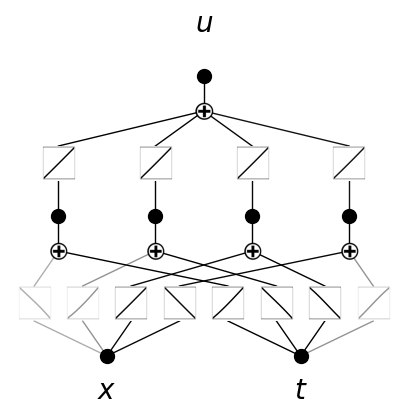

In [182]:
pikan.solution_u = KAN.loadckpt('../Notebooks/ckpt_path/pikan_tju_var2/solution_u/0.1')
pikan.solution_u.plot(folder="../Images/pikan_tju_var2/paper_img/kan1_fit_1/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

saving model version 1.2


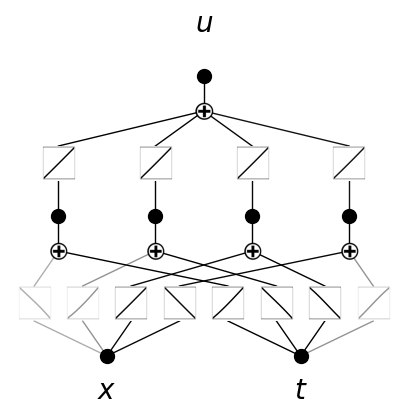

In [184]:
pikan.solution_u = pikan.solution_u.prune()
pikan.solution_u.plot(folder="../Images/pikan_tju_var2/paper_img/kan1_prune_1/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

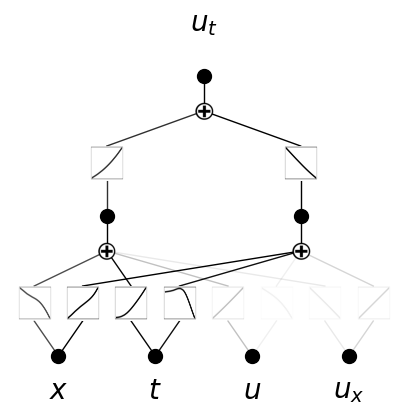

In [183]:
pikan.dynamical_F = KAN.loadckpt('../Notebooks/ckpt_path/pikan_tju_var2/dynamical_F/0.1')
pikan.dynamical_F.plot(folder="../Images/pikan_tju_var2/paper_img/kan2_fit_1/full_png", in_vars=[r'$x$', r'$t$', r'$u$', r'$u_x$'], out_vars=[r'$u_t$'])

saving model version 1.2


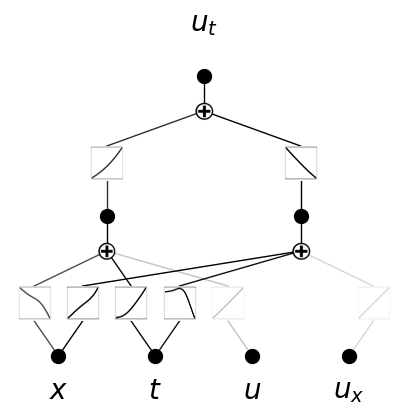

In [185]:
pikan.dynamical_F = pikan.dynamical_F.prune()
pikan.dynamical_F.plot(folder="../Images/pikan_tju_var2/paper_img/kan2_prune_1/full_png", in_vars=[r'$x$', r'$t$', r'$u$', r'$u_x$'], out_vars=[r'$u_t$'])

In [186]:
args.mark = '1.2'
args.epochs = 100
args.save_folder = '../Notebooks/results_of_pikan/TJU results/pikan_fit_2'
args.image_folder = '../Images/pikan_tju_var2/video_img_fit_2'
pikan = PIKAN(args)
pikan.Train(trainloader=train_loader,validloader=valid_loader,testloader=test_loader)

saving model version 2.3
saving model version 2.3
saving model version 2.4
saving model version 2.4


In [258]:
args.mark = '2.4'
pikan = PIKAN(args)
true_label, pred_label = pikan.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for PIKAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

Metrics for PIKAN forecast: MAE:0.005350785795599222, MAPE:0.00675165792927146, MSE:4.989775698049925e-05, RMSE:0.007063834462314844


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

In [188]:
video_name='pikan_tju_var2'
fps=10

for name in ['solution_u','dynamical_F']:
    all_image_files = []
    image_folder = args.image_folder + '/' + name
    files = os.listdir(image_folder)
    train_index = []
    for file in files:
        if file[0].isdigit() and file.endswith('.jpg'):
            train_index.append(int(file[:-4]))
    train_index = np.sort(train_index)
    image_files = [image_folder+'/'+str(index)+'.jpg' for index in train_index]
    all_image_files += image_files
    all_image_files.append(all_image_files[-1])
    clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(all_image_files, fps=fps)
    output_path = "../Videos/"+video_name+'/video_fit_2/'+name+".mp4"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    clip.write_videofile(output_path)

image_folder_solution = os.path.join(args.image_folder, 'solution_u')  # solution_u 文件夹路径
image_folder_dynamical = os.path.join(args.image_folder, 'dynamical_F')  # dynamical_F 文件夹路径

# 步骤1：获取两个文件夹中共同的图片索引（确保名称一致）
def get_common_indices(folder1, folder2):
    # 获取 folder1 中所有数字命名的 jpg 图片索引
    indices1 = []
    for file in os.listdir(folder1):
        if file[0].isdigit() and file.endswith('.jpg'):
            indices1.append(int(file[:-4]))
    # 获取 folder2 中所有数字命名的 jpg 图片索引
    indices2 = []
    for file in os.listdir(folder2):
        if file[0].isdigit() and file.endswith('.jpg'):
            indices2.append(int(file[:-4]))
    # 取交集并排序（确保顺序一致）
    common_indices = sorted(list(set(indices1) & set(indices2)))
    return common_indices

common_indices = get_common_indices(image_folder_solution, image_folder_dynamical)

# 步骤2：拼接同名图片（横向并列）
merged_images = []
for idx in common_indices:
    # 读取 solution_u 的图片
    img_solution_path = os.path.join(image_folder_solution, f"{idx}.jpg")
    img_solution = Image.open(img_solution_path)
    # 读取 dynamical_F 的图片
    img_dynamical_path = os.path.join(image_folder_dynamical, f"{idx}.jpg")
    img_dynamical = Image.open(img_dynamical_path)
    
    # 确保两张图片尺寸一致（不一致时可resize）
    if img_solution.size != img_dynamical.size:
        # 示例：将 dynamical_F 图片 resize 为 solution_u 的尺寸（根据需求调整）
        img_dynamical = img_dynamical.resize(img_solution.size)
    
    # 横向拼接（左右并列）
    merged_img = Image.new('RGB', (img_solution.width + img_dynamical.width, img_solution.height))
    merged_img.paste(img_solution, (0, 0))
    merged_img.paste(img_dynamical, (img_solution.width, 0))
    
    # 纵向拼接（上下并列，可选）
    # merged_img = Image.new('RGB', (img_solution.width, img_solution.height + img_dynamical.height))
    # merged_img.paste(img_solution, (0, 0))
    # merged_img.paste(img_dynamical, (0, img_solution.height))
    
    # 保存拼接后的图片到内存（或临时路径）
    merged_images.append(merged_img)
merged_images.append(merged_images[-1])

# 步骤3：生成合并后的视频（需要将 PIL.Image 对象转为文件路径或数组）
# 注意：moviepy 的 ImageSequenceClip 需要图片路径或 numpy 数组，这里转为数组
merged_frames = [np.array(img) for img in merged_images]

# 生成视频
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(merged_frames, fps=fps)
output_path = os.path.join("../Videos/", video_name, 'video_fit_2', 'merged_video.mp4')
os.makedirs(os.path.dirname(output_path), exist_ok=True)  # 确保输出目录存在
clip.write_videofile(output_path)

MoviePy - Building video ../Videos/pikan_tju_var2/video_fit_2/solution_u.mp4.
MoviePy - Writing video ../Videos/pikan_tju_var2/video_fit_2/solution_u.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/pikan_tju_var2/video_fit_2/solution_u.mp4
MoviePy - Building video ../Videos/pikan_tju_var2/video_fit_2/dynamical_F.mp4.
MoviePy - Writing video ../Videos/pikan_tju_var2/video_fit_2/dynamical_F.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/pikan_tju_var2/video_fit_2/dynamical_F.mp4
MoviePy - Building video ../Videos/pikan_tju_var2/video_fit_2/merged_video.mp4.
MoviePy - Writing video ../Videos/pikan_tju_var2/video_fit_2/merged_video.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/pikan_tju_var2/video_fit_2/merged_video.mp4


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

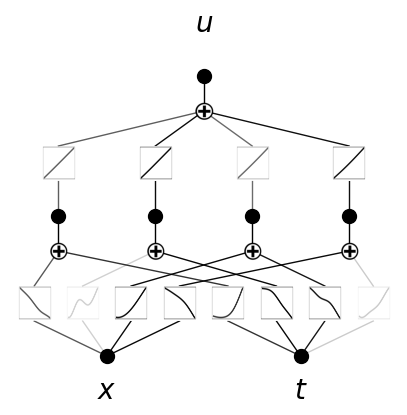

In [259]:
pikan.solution_u = KAN.loadckpt('../Notebooks/ckpt_path/pikan_tju_var2/solution_u/2.4')
pikan.solution_u.plot(folder="../Images/pikan_tju_var2/paper_img/kan1_fit_2/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

saving model version 3.5


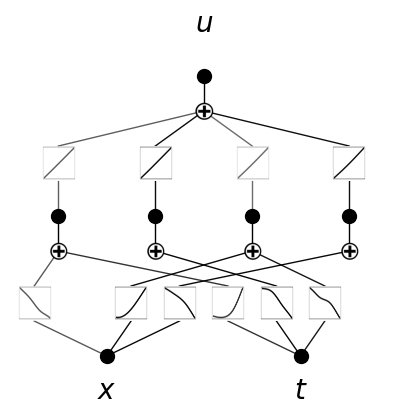

In [260]:
pikan.solution_u = pikan.solution_u.prune(edge_th=0.1)
pikan.solution_u.plot(folder="../Images/pikan_tju_var2/paper_img/kan1_prune_2/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

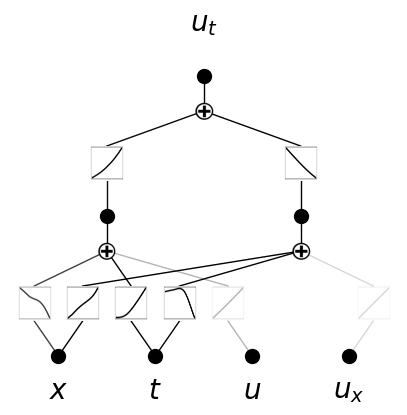

In [261]:
pikan.dynamical_F = KAN.loadckpt('../Notebooks/ckpt_path/pikan_tju_var2/dynamical_F/2.4')
pikan.dynamical_F.plot(folder="../Images/pikan_tju_var2/paper_img/kan2_fit_2/full_png", in_vars=[r'$x$', r'$t$', r'$u$', r'$u_x$'], out_vars=[r'$u_t$'])

saving model version 3.5


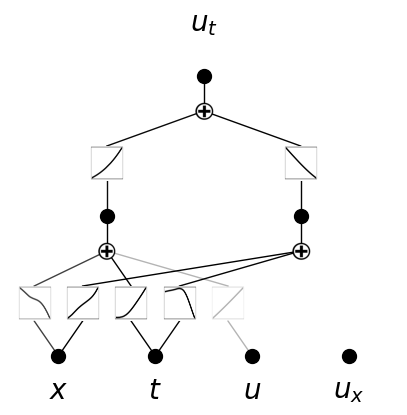

In [262]:
pikan.dynamical_F = pikan.dynamical_F.prune(edge_th=0.1)
pikan.dynamical_F.plot(folder="../Images/pikan_tju_var2/paper_img/kan2_prune_2/full_png", in_vars=[r'$x$', r'$t$', r'$u$', r'$u_x$'], out_vars=[r'$u_t$'])

In [263]:
args.mark = '3.5'
args.epochs = 50
args.save_folder = '../Notebooks/results_of_pikan/TJU results/pikan_fit_3'
args.image_folder = '../Images/pikan_tju_var2/video_img_fit_3'
pikan = PIKAN(args)
pikan.Train(trainloader=train_loader,validloader=valid_loader,testloader=test_loader)

saving model version 4.6
saving model version 4.6
saving model version 4.7
saving model version 4.7


In [268]:
args.mark = '4.7'
pikan = PIKAN(args)
true_label, pred_label = pikan.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for PIKAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

Metrics for PIKAN forecast: MAE:0.005474091973155737, MAPE:0.006884539034217596, MSE:3.399039997020736e-05, RMSE:0.00583012867718935


In [265]:
video_name='pikan_tju_var2'
fps=10

for name in ['solution_u','dynamical_F']:
    all_image_files = []
    image_folder = args.image_folder + '/' + name
    files = os.listdir(image_folder)
    train_index = []
    for file in files:
        if file[0].isdigit() and file.endswith('.jpg'):
            train_index.append(int(file[:-4]))
    train_index = np.sort(train_index)
    image_files = [image_folder+'/'+str(index)+'.jpg' for index in train_index]
    all_image_files += image_files
    all_image_files.append(all_image_files[-1])
    clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(all_image_files, fps=fps)
    output_path = "../Videos/"+video_name+'/video_fit_3/'+name+".mp4"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    clip.write_videofile(output_path)

image_folder_solution = os.path.join(args.image_folder, 'solution_u')  # solution_u 文件夹路径
image_folder_dynamical = os.path.join(args.image_folder, 'dynamical_F')  # dynamical_F 文件夹路径

# 步骤1：获取两个文件夹中共同的图片索引（确保名称一致）
def get_common_indices(folder1, folder2):
    # 获取 folder1 中所有数字命名的 jpg 图片索引
    indices1 = []
    for file in os.listdir(folder1):
        if file[0].isdigit() and file.endswith('.jpg'):
            indices1.append(int(file[:-4]))
    # 获取 folder2 中所有数字命名的 jpg 图片索引
    indices2 = []
    for file in os.listdir(folder2):
        if file[0].isdigit() and file.endswith('.jpg'):
            indices2.append(int(file[:-4]))
    # 取交集并排序（确保顺序一致）
    common_indices = sorted(list(set(indices1) & set(indices2)))
    return common_indices

common_indices = get_common_indices(image_folder_solution, image_folder_dynamical)

# 步骤2：拼接同名图片（横向并列）
merged_images = []
for idx in common_indices:
    # 读取 solution_u 的图片
    img_solution_path = os.path.join(image_folder_solution, f"{idx}.jpg")
    img_solution = Image.open(img_solution_path)
    # 读取 dynamical_F 的图片
    img_dynamical_path = os.path.join(image_folder_dynamical, f"{idx}.jpg")
    img_dynamical = Image.open(img_dynamical_path)
    
    # 确保两张图片尺寸一致（不一致时可resize）
    if img_solution.size != img_dynamical.size:
        # 示例：将 dynamical_F 图片 resize 为 solution_u 的尺寸（根据需求调整）
        img_dynamical = img_dynamical.resize(img_solution.size)
    
    # 横向拼接（左右并列）
    merged_img = Image.new('RGB', (img_solution.width + img_dynamical.width, img_solution.height))
    merged_img.paste(img_solution, (0, 0))
    merged_img.paste(img_dynamical, (img_solution.width, 0))
    
    # 纵向拼接（上下并列，可选）
    # merged_img = Image.new('RGB', (img_solution.width, img_solution.height + img_dynamical.height))
    # merged_img.paste(img_solution, (0, 0))
    # merged_img.paste(img_dynamical, (0, img_solution.height))
    
    # 保存拼接后的图片到内存（或临时路径）
    merged_images.append(merged_img)
merged_images.append(merged_images[-1])

# 步骤3：生成合并后的视频（需要将 PIL.Image 对象转为文件路径或数组）
# 注意：moviepy 的 ImageSequenceClip 需要图片路径或 numpy 数组，这里转为数组
merged_frames = [np.array(img) for img in merged_images]

# 生成视频
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(merged_frames, fps=fps)
output_path = os.path.join("../Videos/", video_name, 'video_fit_3', 'merged_video.mp4')
os.makedirs(os.path.dirname(output_path), exist_ok=True)  # 确保输出目录存在
clip.write_videofile(output_path)

MoviePy - Building video ../Videos/pikan_tju_var2/video_fit_3/solution_u.mp4.
MoviePy - Writing video ../Videos/pikan_tju_var2/video_fit_3/solution_u.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/pikan_tju_var2/video_fit_3/solution_u.mp4
MoviePy - Building video ../Videos/pikan_tju_var2/video_fit_3/dynamical_F.mp4.
MoviePy - Writing video ../Videos/pikan_tju_var2/video_fit_3/dynamical_F.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/pikan_tju_var2/video_fit_3/dynamical_F.mp4
MoviePy - Building video ../Videos/pikan_tju_var2/video_fit_3/merged_video.mp4.
MoviePy - Writing video ../Videos/pikan_tju_var2/video_fit_3/merged_video.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/pikan_tju_var2/video_fit_3/merged_video.mp4


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

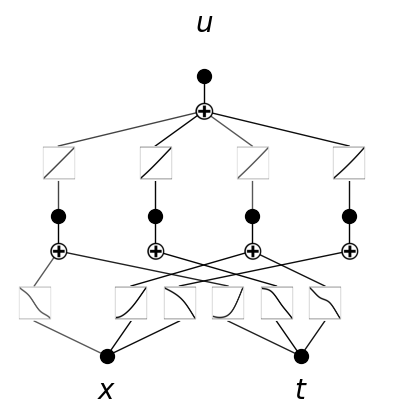

In [269]:
pikan.solution_u = KAN.loadckpt('../Notebooks/ckpt_path/pikan_tju_var2/solution_u/4.7')
pikan.solution_u.plot(folder="../Images/pikan_tju_var2/paper_img/kan1_fit_3/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

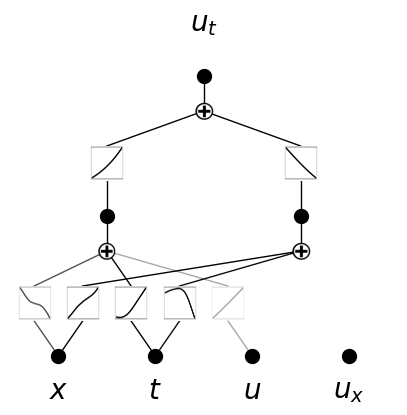

In [270]:
pikan.dynamical_F = KAN.loadckpt('../Notebooks/ckpt_path/pikan_tju_var2/dynamical_F/4.7')
pikan.dynamical_F.plot(folder="../Images/pikan_tju_var2/paper_img/kan2_fit_3/full_png", in_vars=[r'$x$', r'$t$', r'$u$', r'$u_x$'], out_vars=[r'$u_t$'])

In [8]:
add_symbolic('bessel_j0',torch.special.bessel_j0)
add_symbolic('erf',torch.special.erf)
add_symbolic('sinc',torch.special.sinc)
add_symbolic('softmax',lambda x: torch.special.softmax(x, dim=0))
add_symbolic('sigmoid', torch.sigmoid)
add_symbolic('relu',torch.relu)
add_symbolic('cosh',torch.cosh)
add_symbolic('sinh',torch.sinh)
add_symbolic('arcsinh',torch.arcsinh)
add_symbolic('arccosh',torch.arccosh)

In [272]:
pikan.solution_u.auto_symbolic()

fixing (0,0,0) with arcsinh, r2=0.9997881650924683, c=1
fixing (0,0,1) with 0
fixing (0,0,2) with bessel_j0, r2=0.9999927878379822, c=1
fixing (0,0,3) with arcsinh, r2=0.9999815821647644, c=1
fixing (0,1,0) with erf, r2=0.999519944190979, c=1
fixing (0,1,1) with sinc, r2=0.9994828104972839, c=1
fixing (0,1,2) with sinh, r2=0.9966912269592285, c=1
fixing (0,1,3) with 0
fixing (1,0,0) with sinh, r2=0.9999991059303284, c=1
fixing (1,1,0) with arcsinh, r2=0.9999935626983643, c=1
fixing (1,2,0) with sinh, r2=0.9999993443489075, c=1
fixing (1,3,0) with cosh, r2=1.000000238418579, c=1
saving model version 5.8


In [273]:
pikan.dynamical_F.auto_symbolic()

fixing (0,0,0) with sinh, r2=0.9971842169761658, c=1
fixing (0,0,1) with sinh, r2=0.998532772064209, c=1
fixing (0,1,0) with bessel_j0, r2=0.9998484253883362, c=1
fixing (0,1,1) with cosh, r2=0.992497980594635, c=1
fixing (0,2,0) with sinh, r2=0.9999986290931702, c=1
fixing (0,2,1) with 0
fixing (0,3,0) with 0
fixing (0,3,1) with 0
fixing (1,0,0) with cosh, r2=0.999996542930603, c=1
fixing (1,1,0) with sinh, r2=0.9999608397483826, c=1
saving model version 5.8


In [9]:
args.mark = '5.8'
pikan = PIKAN(args)
true_label, pred_label = pikan.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for PIKAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

Metrics for PIKAN forecast: MAE:0.005679429974406958, MAPE:0.007186580915004015, MSE:3.8836751627968624e-05, RMSE:0.006231913808733225


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

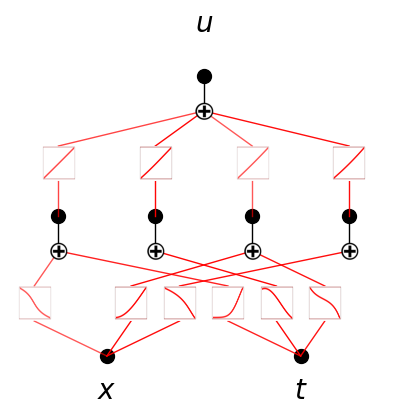

In [10]:
pikan.solution_u = KAN.loadckpt('../Notebooks/ckpt_path/pikan_tju_var2/solution_u/5.8')
pikan.solution_u.plot(folder="../Images/pikan_tju_var2/paper_img/kan1_symbolic_1/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

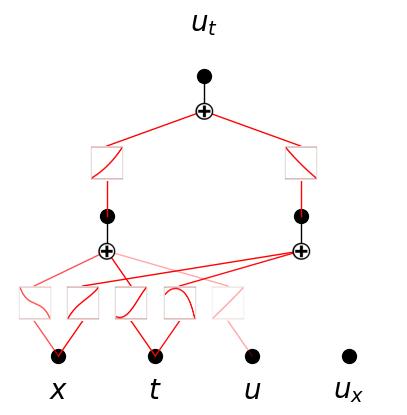

In [16]:
pikan.dynamical_F = KAN.loadckpt('../Notebooks/ckpt_path/pikan_tju_var2/dynamical_F/5.8')
pikan.dynamical_F.plot(folder="../Images/pikan_tju_var2/paper_img/kan2_symbolic_1/full_png", in_vars=[r'$x$', r'$t$', r'$u$', r'$u_x$'], out_vars=[r'$u_t$'],beta=3)

In [17]:
formula1, variables1 = pikan.solution_u.symbolic_formula(var=[r'x', r't'])
print(formula1[0])
print(ex_round(formula1[0],5))

-0.249949648976326*arcsinh(5.03452195037011*sinc(-0.441119849681854*t - 3.81832003593445) + 0.341968498761245) - 0.000715181056875736*sinh(-0.00744976713721901*arcsinh(-3.34159994125366*x - 0.174000024795532) + 0.0353013256481391*erf(1.19063985347748 - 1.50415992736816*t) - 8.86276162442957) - 6.04320630372968e-5*sinh(0.40720468511779*bessel_j0(-0.963679790496826*x - 0.977759838104248) - 0.0362198761733712*sinh(-2.07479977607727*t - 0.230239987373352) - 10.2940797181622) + 8.51553922984749e-5*cosh(-0.112110662136498*arcsinh(1.57663977146149 - 2.08831977844238*x) - 9.54945201868599) - 2.95423007011414
-0.24995*arcsinh(5.03452*sinc(-0.44112*t - 3.81832) + 0.34197) - 0.00072*sinh(-0.00745*arcsinh(-3.3416*x - 0.174) + 0.0353*erf(1.19064 - 1.50416*t) - 8.86276) - 6.0e-5*sinh(0.4072*bessel_j0(-0.96368*x - 0.97776) - 0.03622*sinh(-2.0748*t - 0.23024) - 10.29408) + 9.0e-5*cosh(-0.11211*arcsinh(1.57664 - 2.08832*x) - 9.54945) - 2.95423


In [13]:
formula2, variables2 = pikan.dynamical_F.symbolic_formula(var=[r'x', r't', r'u', r'u_x'])
print(formula2[0])
print(ex_round(formula2[0],5))

4.74888911412563e-5*sinh(0.128474256203079*sinh(0.186399862170219 - 1.3472797870636*x) + 0.0495883524412744*cosh(-2.11271977424622*t - 0.674159824848175) + 7.87102749722097) + 3.83408878406044e-5*cosh(-1.06545726678472*bessel_j0(2.56815981864929 - 1.72103989124298*t) + 0.000124217188693891*sinh(-0.493359833955765*u - 9.28800010681152) - 0.0342333384752722*sinh(-2.70391988754272*x - 0.0092799998819828) - 5.99805516143358) - 0.215642027556896
5.0e-5*sinh(0.12847*sinh(0.1864 - 1.34728*x) + 0.04959*cosh(-2.11272*t - 0.67416) + 7.87103) + 4.0e-5*cosh(-1.06546*bessel_j0(2.56816 - 1.72104*t) + 0.00012*sinh(-0.49336*u - 9.288) - 0.03423*sinh(-2.70392*x - 0.00928) - 5.99806) - 0.21564


In [9]:
def complex_expression_kan1_1(input):
    # Unpack inputs
    x, t = input

    # First part of the expression
    Eq = -0.249949648976326*torch.arcsinh(5.03452195037011*torch.special.sinc(-0.441119849681854*t - 3.81832003593445) + 0.341968498761245) \
    - 0.000715181056875736*torch.sinh(-0.00744976713721901*torch.arcsinh(-3.34159994125366*x - 0.174000024795532) \
    + 0.0353013256481391*torch.special.erf(1.19063985347748 - 1.50415992736816*t) - 8.86276162442957) \
    - 6.04320630372968e-5*torch.sinh(0.40720468511779*torch.special.bessel_j0(-0.963679790496826*x - 0.977759838104248) \
    - 0.0362198761733712*torch.sinh(-2.07479977607727*t - 0.230239987373352) - 10.2940797181622) \
    + 8.51553922984749e-5*torch.cosh(-0.112110662136498*torch.arcsinh(1.57663977146149 - 2.08831977844238*x) - 9.54945201868599) - 2.95423007011414

    # Return the result as a tensor
    return torch.tensor([Eq])

In [10]:
def complex_expression_kan1(input):
    # Unpack inputs
    x, t = input

    # First part of the expression
    Eq = -0.2499*torch.arcsinh(5.0345*torch.special.sinc(-0.4411*t - 3.8183) + 0.342) \
    - 0.0007*torch.sinh(-0.0074*torch.arcsinh(-3.3416*x - 0.174) \
    + 0.0353*torch.special.erf(1.1906 - 1.5042*t) - 8.8628) \
    - 0.e-4*torch.sinh(0.4072*torch.special.bessel_j0(-0.9637*x - 0.9778) \
    - 0.0362*torch.sinh(-2.0748*t - 0.2302) - 10.2941) \
    + 0.0001*torch.cosh(-0.1121*torch.arcsinh(1.5766 - 2.0883*x) - 9.5495) - 2.9542

    # Return the result as a tensor
    return torch.tensor([Eq])

In [ ]:
args.mark = '4.7'
pikan = PIKAN(args)
true_label, pred_label = pikan.Test(testloader=test_loader)

symbolic_forecast = []
symbolic_forecast1 = []
with torch.no_grad():
    for iter,(x1,_,y1,_) in enumerate(test_loader):
        for i in range(x1.shape[0]):
            input = x1[i]
            symbolic_result = complex_expression_kan1(input) 
            symbolic_forecast.append(symbolic_result.cpu().numpy())  
            symbolic_result1 = complex_expression_kan1_1(input)  
            symbolic_forecast1.append(symbolic_result1.cpu().numpy())  

symbolic_forecast = np.array(symbolic_forecast)
symbolic_forecast1 = np.array(symbolic_forecast1)

pikan_metrics = eval_metrix(true_label, pred_label)
symbolic_metrics = eval_metrix(true_label, symbolic_forecast)
symbolic_metrics1 = eval_metrix(true_label, symbolic_forecast1)

print(f"Metrics for PIKAN forecast: MAE:{pikan_metrics[0]}, MAPE:{pikan_metrics[1]}, MSE:{pikan_metrics[2]}, RMSE:{pikan_metrics[3]}")
print(f"Metrics for Symbolic forecast: MAE:{symbolic_metrics[0]}, MAPE:{symbolic_metrics[1]}, MSE:{symbolic_metrics[2]}, RMSE:{symbolic_metrics[3]}")
print(f"Metrics for Symbolic forecast 1: MAE:{symbolic_metrics1[0]}, MAPE:{symbolic_metrics1[1]}, MSE:{symbolic_metrics1[2]}, RMSE:{symbolic_metrics1[3]}")

viz_folder = '../Notebooks/viz_folder'
if not os.path.exists(viz_folder):
    os.makedirs(viz_folder)
np.save(os.path.join(viz_folder, 'tju_batch_2_true_values.npy'), true_label)
np.save(os.path.join(viz_folder, 'tju_batch_2_pikan_model_forecast.npy'), pred_label)
np.save(os.path.join(viz_folder, 'tju_batch_2_pikan_symbolic_forecast.npy'), symbolic_forecast1)


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

Metrics for PIKAN forecast: MAE:0.005474091973155737, MAPE:0.006895455997437239, MSE:3.399039997020736e-05, RMSE:0.00583012867718935
Metrics for Symbolic forecast: MAE:0.609260618686676, MAPE:0.779521644115448, MSE:0.37210506200790405, RMSE:0.6100041270256042
Metrics for Symbolic forecast 1: MAE:0.005679367575794458, MAPE:0.007189671974629164, MSE:3.883623139699921e-05, RMSE:0.0062318723648786545


image saved at ../Images/pikan_tju_var2/paper_img/reality_vs_pikan_vs_symbolic_first400.png


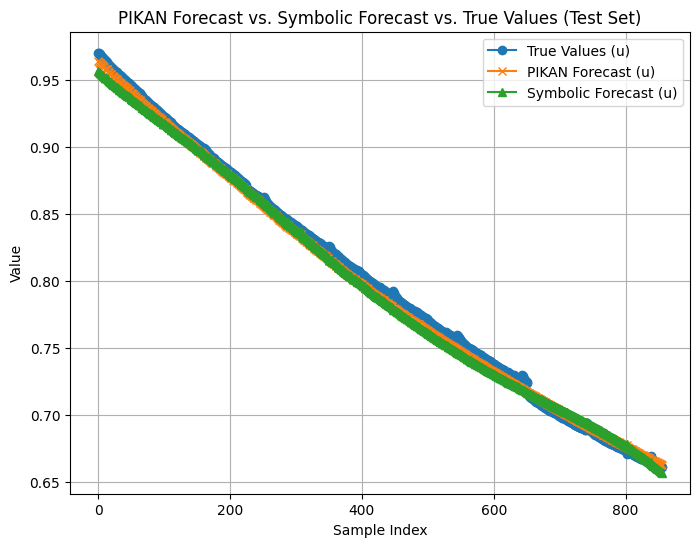

In [292]:
import matplotlib.pyplot as plt

# Set the interval for the samples to plot
interval = 856

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the KAN forecasts and symbolic forecasts against the true values for id_k1
plt.plot(true_label[:interval], label='True Values (u)', marker='o')
plt.plot(pred_label[:interval], label='PIKAN Forecast (u)', marker='x')
plt.plot(symbolic_forecast1[:interval], label='Symbolic Forecast (u)', marker='^')
# plt.ylim(0.79, 1.01)
# plt.yticks(np.arange(0.80, 1.01, 0.05))

# Customize the plot
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('PIKAN Forecast vs. Symbolic Forecast vs. True Values (Test Set)')
plt.legend()
plt.grid(True)

# Save the plot to a specific location
save_path = '../Images/pikan_tju_var2/paper_img/reality_vs_pikan_vs_symbolic_first400.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)

# Show the plot
plt.show()

image saved at ../Images/pikan_tju_var2/paper_img/reality_vs_pikan_vs_symbolic.png


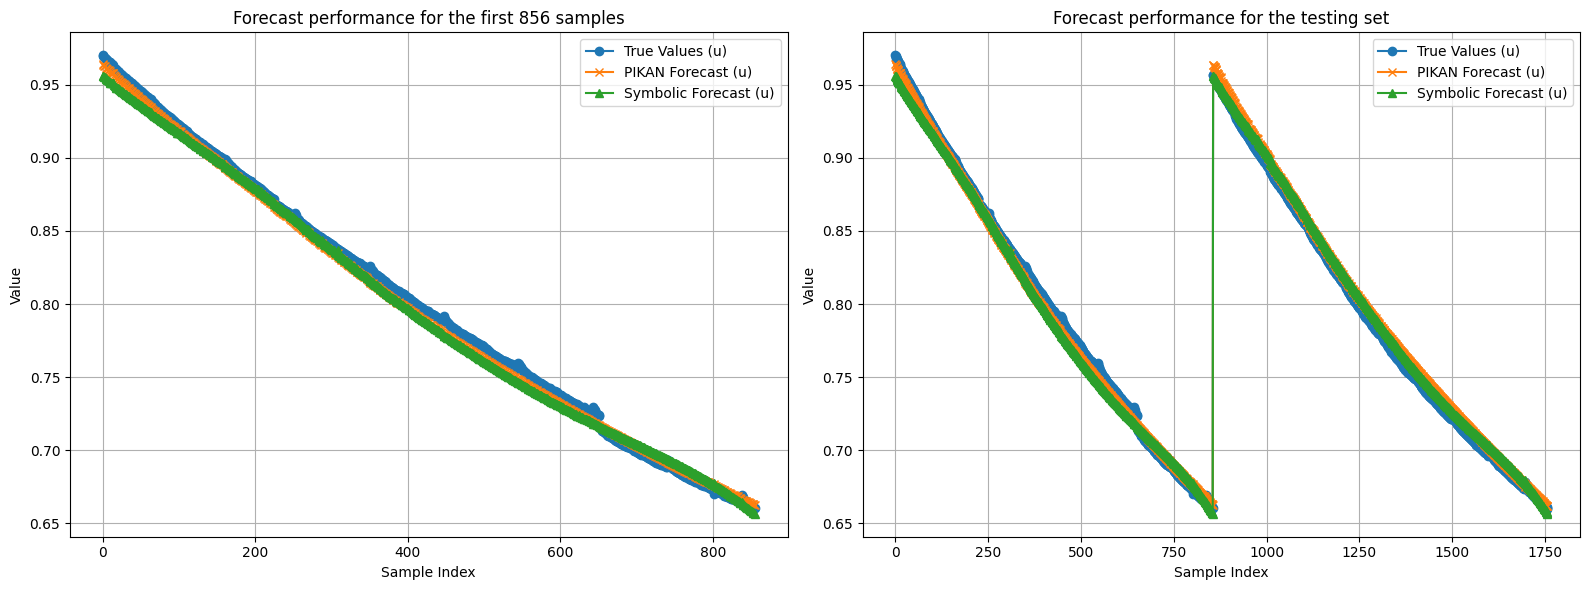

In [291]:
import matplotlib.pyplot as plt

# Set the interval for the first plot (first 50 samples)
interval = 856

# Create the figure and axes for side-by-side plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the first interval 
axes[0].plot(true_label[:interval], label='True Values (u)', marker='o')
axes[0].plot(pred_label[:interval], label='PIKAN Forecast (u)', marker='x')
axes[0].plot(symbolic_forecast1[:interval], label='Symbolic Forecast (u)', marker='^')
# axes[0].set(ylim=(0.79, 1.01),yticks=np.arange(0.80, 1.01, 0.05))

# Set the title and labels for the first plot
axes[0].set_title(f'Forecast performance for the first {interval} samples')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True)

# Plot the second interval (entire dataset)
axes[1].plot(true_label, label='True Values (u)', marker='o')
axes[1].plot(pred_label, label='PIKAN Forecast (u)', marker='x')
axes[1].plot(symbolic_forecast1, label='Symbolic Forecast (u)', marker='^')
# axes[1].set(ylim=(0.81, 1.04),yticks=np.arange(0.85, 1.00, 0.05))

# Set the title and labels for the second plot
axes[1].set_title('Forecast performance for the testing set')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True)

# Save the plot to a specific location
save_path = '../Images/pikan_tju_var2/paper_img/reality_vs_pikan_vs_symbolic.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [293]:
import gc
torch.cuda.empty_cache()
gc.collect()

4792217